## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

SEED = 42
np.random.seed(SEED)

print("Librerías cargadas")

Librerías cargadas


In [2]:
# Cargar datos
X_train = np.load('../data/processed/X_train.npy')
X_val = np.load('../data/processed/X_val.npy')
X_test = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_val = np.load('../data/processed/y_val.npy')
y_test = np.load('../data/processed/y_test.npy')

with open('../data/processed/feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

# Convertir a DataFrames
X_train_df = pd.DataFrame(X_train, columns=feature_cols)
X_val_df = pd.DataFrame(X_val, columns=feature_cols)
X_test_df = pd.DataFrame(X_test, columns=feature_cols)

print(f"Datos cargados:")
print(f"  TRAIN: {X_train.shape} (1970-2004)")
print(f"  VAL:   {X_val.shape} (2005-2013)")
print(f"  TEST:  {X_test.shape} (2014-2025)")

Datos cargados:
  TRAIN: (67229, 31) (1970-2004)
  VAL:   (15175, 31) (2005-2013)
  TEST:  (22203, 31) (2014-2025)


## 2. Modelo Baseline - XGBoost (X)

Resultados del Notebook 04:
- **R² = 0.8761**
- **RMSE = 1179.55**
- **MAE = 590.83**

Hiperparámetros baseline:
- n_estimators: 200
- max_depth: 6
- learning_rate: 0.1
- subsample: 0.8
- colsample_bytree: 0.8

In [3]:
# Cargar modelo baseline
with open('../models/xgb_x.pkl', 'rb') as f:
    xgb_baseline = pickle.load(f)

print("Modelo XGBoost baseline cargado")
print(f"\nHiperparámetros actuales:")
print(f"  n_estimators: {xgb_baseline.n_estimators}")
print(f"  max_depth: {xgb_baseline.max_depth}")
print(f"  learning_rate: {xgb_baseline.learning_rate}")
print(f"  subsample: {xgb_baseline.subsample}")
print(f"  colsample_bytree: {xgb_baseline.colsample_bytree}")

Modelo XGBoost baseline cargado

Hiperparámetros actuales:
  n_estimators: 200
  max_depth: 6
  learning_rate: 0.1
  subsample: 0.8
  colsample_bytree: 0.8


In [4]:
# Evaluar baseline en VAL
y_val_pred_baseline = xgb_baseline.predict(X_val_df)

r2_baseline = r2_score(y_val, y_val_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_val, y_val_pred_baseline))
mae_baseline = mean_absolute_error(y_val, y_val_pred_baseline)

print("="*70)
print("RESULTADOS BASELINE EN VALIDATION")
print("="*70)
print(f"R²:   {r2_baseline:.4f}")
print(f"RMSE: {rmse_baseline:.4f}")
print(f"MAE:  {mae_baseline:.4f}")
print("="*70)

RESULTADOS BASELINE EN VALIDATION
R²:   0.8761
RMSE: 1179.5539
MAE:  590.8282


## 3. Optimización de Hiperparámetros

Usaremos `RandomizedSearchCV` para explorar un espacio amplio de hiperparámetros.

In [5]:
# Espacio de búsqueda de hiperparámetros
param_distributions = {
    'n_estimators': [100, 200, 300, 400, 500, 600, 800],
    'max_depth': [3, 4, 5, 6, 7, 8, 10, 12],
    'learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1, 0.15, 0.2],
    'subsample': [0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0],
    'min_child_weight': [1, 2, 3, 4, 5, 7, 10],
    'gamma': [0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5],
    'reg_alpha': [0, 0.001, 0.01, 0.05, 0.1, 0.5, 1],
    'reg_lambda': [0.1, 0.5, 1, 2, 5, 10, 20]
}

print("Espacio de búsqueda definido:")
for param, values in param_distributions.items():
    print(f"  {param}: {len(values)} valores")

print(f"\nTotal de combinaciones posibles: {np.prod([len(v) for v in param_distributions.values()]):,}")
print(f"Probaremos: 100 combinaciones aleatorias")

Espacio de búsqueda definido:
  n_estimators: 7 valores
  max_depth: 8 valores
  learning_rate: 7 valores
  subsample: 8 valores
  colsample_bytree: 8 valores
  min_child_weight: 7 valores
  gamma: 7 valores
  reg_alpha: 7 valores
  reg_lambda: 7 valores

Total de combinaciones posibles: 60,236,288
Probaremos: 100 combinaciones aleatorias


In [6]:
print("="*70)
print("INICIANDO BÚSQUEDA DE HIPERPARÁMETROS")
print("="*70)
print("Método: RandomizedSearchCV")
print("Iteraciones: 100")
print("Cross-Validation: 3 folds")
print("Métrica: RMSE (neg_root_mean_squared_error)")
print("\nEsto puede tardar varios minutos...\n")

# Crear búsqueda
random_search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(random_state=SEED, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=100,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2,
    random_state=SEED
)

# Ejecutar búsqueda
random_search.fit(X_train_df, y_train)

print("\n" + "="*70)
print("BÚSQUEDA COMPLETADA")
print("="*70)

INICIANDO BÚSQUEDA DE HIPERPARÁMETROS
Método: RandomizedSearchCV
Iteraciones: 100
Cross-Validation: 3 folds
Métrica: RMSE (neg_root_mean_squared_error)

Esto puede tardar varios minutos...

Fitting 3 folds for each of 100 candidates, totalling 300 fits


[CV] END colsample_bytree=0.95, gamma=0.2, learning_rate=0.03, max_depth=3, min_child_weight=7, n_estimators=500, reg_alpha=0.01, reg_lambda=5, subsample=0.95; total time=   1.0s
[CV] END colsample_bytree=0.95, gamma=0.2, learning_rate=0.03, max_depth=3, min_child_weight=7, n_estimators=500, reg_alpha=0.01, reg_lambda=5, subsample=0.95; total time=   1.1s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.15, max_depth=5, min_child_weight=7, n_estimators=300, reg_alpha=0.001, reg_lambda=10, subsample=0.85; total time=   1.1s
[CV] END colsample_bytree=0.95, gamma=0.2, learning_rate=0.03, max_depth=3, min_child_weight=7, n_estimators=500, reg_alpha=0.01, reg_lambda=5, subsample=0.95; total time=   1.0s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.15, max_depth=5, min_child_weight=7, n_estimators=300, reg_alpha=0.001, reg_lambda=10, subsample=0.85; total time=   1.1s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.15, max_depth=5, min_child_weight=7, n_estima

In [7]:
# Mostrar mejores hiperparámetros
print("\n" + "="*70)
print("MEJORES HIPERPARÁMETROS ENCONTRADOS")
print("="*70)
for param, value in sorted(random_search.best_params_.items()):
    print(f"{param:20s}: {value}")

print(f"\nMejor RMSE (CV en TRAIN): {-random_search.best_score_:.4f}")
print("="*70)


MEJORES HIPERPARÁMETROS ENCONTRADOS
colsample_bytree    : 1.0
gamma               : 0.1
learning_rate       : 0.2
max_depth           : 4
min_child_weight    : 3
n_estimators        : 500
reg_alpha           : 1
reg_lambda          : 0.1
subsample           : 0.75

Mejor RMSE (CV en TRAIN): 1437.5937


In [8]:
# Evaluar modelo optimizado en VAL
best_model = random_search.best_estimator_
y_val_pred_optimized = best_model.predict(X_val_df)

r2_optimized = r2_score(y_val, y_val_pred_optimized)
rmse_optimized = np.sqrt(mean_squared_error(y_val, y_val_pred_optimized))
mae_optimized = mean_absolute_error(y_val, y_val_pred_optimized)

print("\n" + "="*70)
print("COMPARACIÓN: BASELINE vs OPTIMIZADO (VALIDATION)")
print("="*70)
comparison = pd.DataFrame([
    {'Modelo': 'Baseline', 'R²': r2_baseline, 'RMSE': rmse_baseline, 'MAE': mae_baseline},
    {'Modelo': 'Optimizado', 'R²': r2_optimized, 'RMSE': rmse_optimized, 'MAE': mae_optimized}
])
print(comparison.to_string(index=False))

# Calcular mejoras
mejora_r2 = ((r2_optimized - r2_baseline) / r2_baseline) * 100
mejora_rmse = ((rmse_baseline - rmse_optimized) / rmse_baseline) * 100
mejora_mae = ((mae_baseline - mae_optimized) / mae_baseline) * 100

print(f"\nMejoras:")
print(f"  R²:   {mejora_r2:+.2f}%")
print(f"  RMSE: {mejora_rmse:+.2f}%")
print(f"  MAE:  {mejora_mae:+.2f}%")
print("="*70)


COMPARACIÓN: BASELINE vs OPTIMIZADO (VALIDATION)
    Modelo       R²        RMSE        MAE
  Baseline 0.876095 1179.553865 590.828236
Optimizado 0.869874 1208.803351 624.568359

Mejoras:
  R²:   -0.71%
  RMSE: -2.48%
  MAE:  -5.71%



Top 15 Features más importantes:
            feature  importance
   produccion_total    0.283848
 sup_sembrada_total    0.213079
    cultivo_encoded    0.157200
     suelo_ind_prod    0.131910
    suelo_porc_sue1    0.064243
   suelo_profund_s1    0.027558
 temperatura_mes_10    0.020425
  temperatura_mes_8    0.018616
  temperatura_mes_7    0.007185
  temperatura_mes_9    0.005619
  temperatura_mes_6    0.004621
 temperatura_mes_11    0.004454
precipitacion_mes_7    0.004389
precipitacion_mes_6    0.004218
precipitacion_mes_4    0.004078


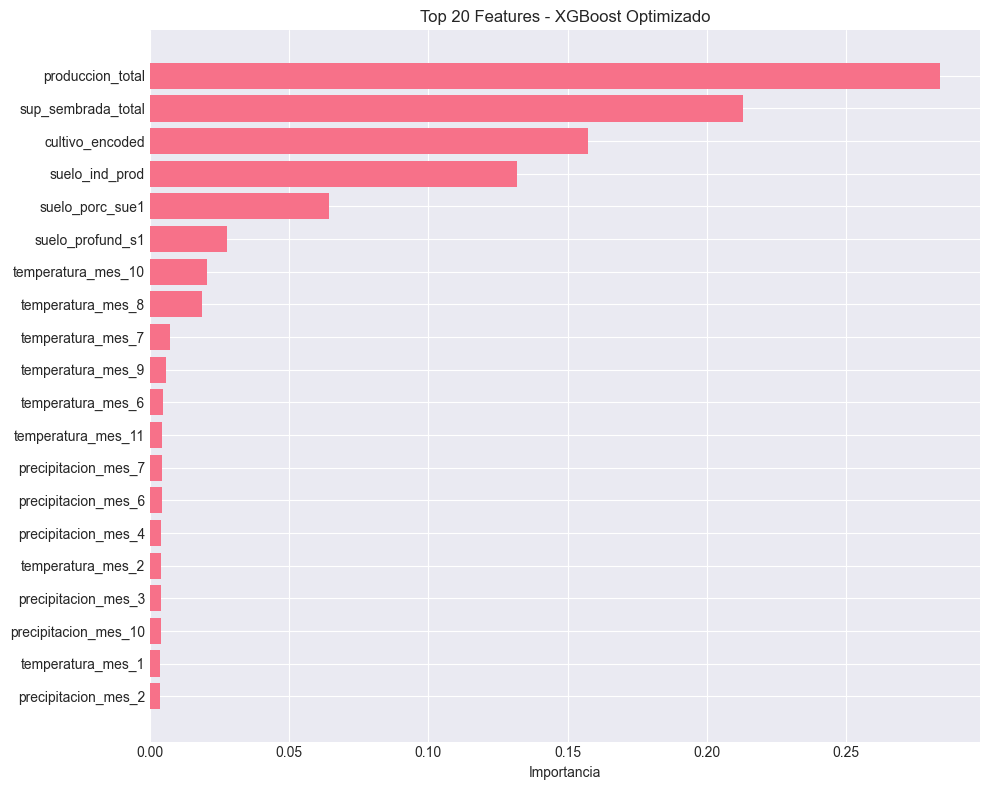

In [9]:
# Feature importance del modelo optimizado
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Features más importantes:")
print(feature_importance.head(15).to_string(index=False))

# Visualización
plt.figure(figsize=(10, 8))
plt.barh(feature_importance.head(20)['feature'], feature_importance.head(20)['importance'])
plt.xlabel('Importancia')
plt.title('Top 20 Features - XGBoost Optimizado')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../figures/xgb_optimized_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Reentrenamiento con DEV (TRAIN + VAL)

In [10]:
print("="*70)
print("REENTRENAMIENTO CON DEV (TRAIN + VAL)")
print("="*70)

# Crear conjunto DEV
X_dev = np.vstack([X_train, X_val])
y_dev = np.concatenate([y_train, y_val])
X_dev_df = pd.DataFrame(X_dev, columns=feature_cols)

print(f"\nDEV:  {X_dev.shape[0]:,} muestras (1970-2013)")
print(f"TEST: {X_test.shape[0]:,} muestras (2014-2025)")
print(f"\nReentrenando XGBoost con hiperparámetros optimizados...")

# Crear modelo final con mejores parámetros
final_model = xgb.XGBRegressor(**random_search.best_params_, random_state=SEED, n_jobs=-1)
final_model.fit(X_dev_df, y_dev)

print("\n✓ Reentrenamiento completado")

# Guardar modelo final
with open('../models/xgb_optimized_final.pkl', 'wb') as f:
    pickle.dump(final_model, f)

print("✓ Modelo guardado en: models/xgb_optimized_final.pkl")

REENTRENAMIENTO CON DEV (TRAIN + VAL)

DEV:  82,404 muestras (1970-2013)
TEST: 22,203 muestras (2014-2025)

Reentrenando XGBoost con hiperparámetros optimizados...

✓ Reentrenamiento completado
✓ Modelo guardado en: models/xgb_optimized_final.pkl


## 5. Evaluación Final en TEST

In [11]:
# Predecir en TEST
y_test_pred = final_model.predict(X_test_df)

# Calcular métricas
r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)

print("\n" + "="*70)
print("🎯 RESULTADOS FINALES EN TEST")
print("="*70)
print("Modelo: XGBoost Optimizado (entrenado con DEV)")
print(f"\nMétricas:")
print(f"  R²:   {r2_test:.4f}")
print(f"  RMSE: {rmse_test:.4f}")
print(f"  MAE:  {mae_test:.4f}")
print("="*70)

print(f"\nComparación con baseline (VAL):")
print(f"  Baseline R²: {r2_baseline:.4f} → Test R²: {r2_test:.4f}")
print(f"  Baseline RMSE: {rmse_baseline:.4f} → Test RMSE: {rmse_test:.4f}")


🎯 RESULTADOS FINALES EN TEST
Modelo: XGBoost Optimizado (entrenado con DEV)

Métricas:
  R²:   0.6505
  RMSE: 1220.2064
  MAE:  684.3691

Comparación con baseline (VAL):
  Baseline R²: 0.8761 → Test R²: 0.6505
  Baseline RMSE: 1179.5539 → Test RMSE: 1220.2064


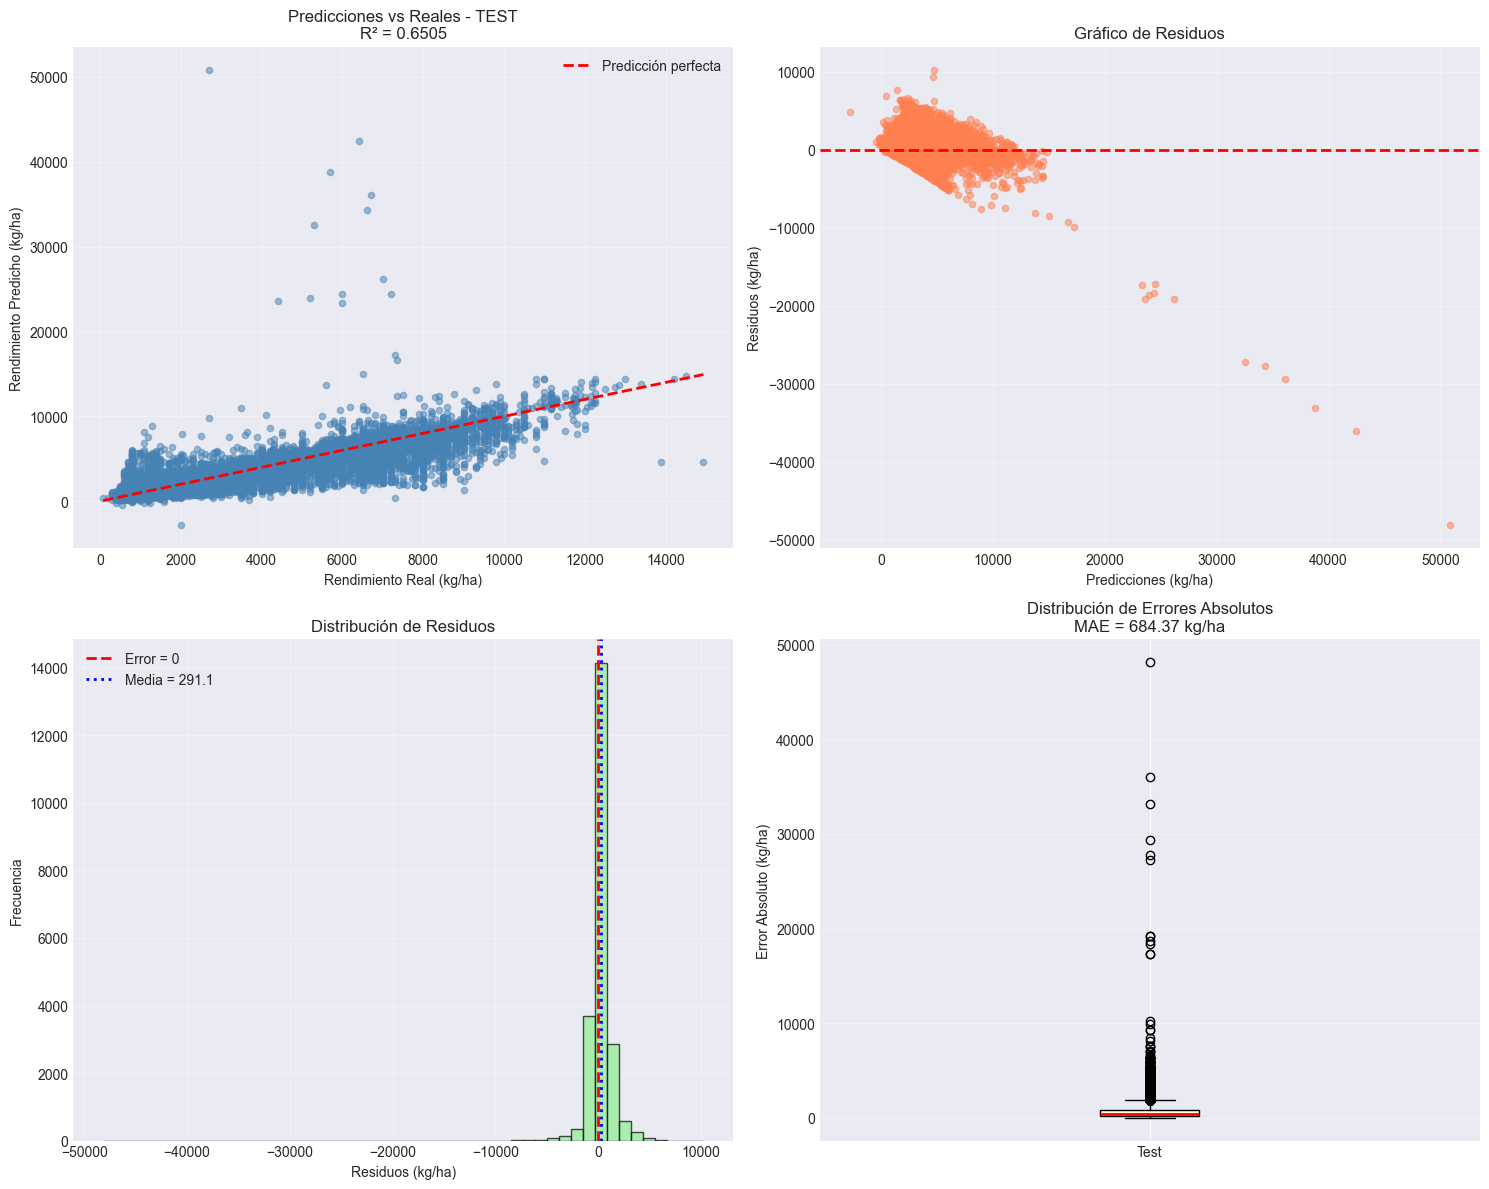

✓ Gráficos guardados en: figures/xgb_final_evaluation.png


In [12]:
# Visualizaciones completas
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Predicciones vs Reales
axes[0, 0].scatter(y_test, y_test_pred, alpha=0.5, s=20, color='steelblue')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                'r--', lw=2, label='Predicción perfecta')
axes[0, 0].set_xlabel('Rendimiento Real (kg/ha)')
axes[0, 0].set_ylabel('Rendimiento Predicho (kg/ha)')
axes[0, 0].set_title(f'Predicciones vs Reales - TEST\nR² = {r2_test:.4f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuos
residuos = y_test - y_test_pred
axes[0, 1].scatter(y_test_pred, residuos, alpha=0.5, s=20, color='coral')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicciones (kg/ha)')
axes[0, 1].set_ylabel('Residuos (kg/ha)')
axes[0, 1].set_title('Gráfico de Residuos')
axes[0, 1].grid(True, alpha=0.3)

# 3. Distribución de residuos
axes[1, 0].hist(residuos, bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2, label='Error = 0')
axes[1, 0].axvline(x=residuos.mean(), color='blue', linestyle=':', lw=2, 
                   label=f'Media = {residuos.mean():.1f}')
axes[1, 0].set_xlabel('Residuos (kg/ha)')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de Residuos')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Boxplot de errores absolutos
axes[1, 1].boxplot(np.abs(residuos), vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightyellow', color='black'),
                   medianprops=dict(color='red', linewidth=2))
axes[1, 1].set_ylabel('Error Absoluto (kg/ha)')
axes[1, 1].set_title(f'Distribución de Errores Absolutos\nMAE = {mae_test:.2f} kg/ha')
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].set_xticklabels(['Test'])

plt.tight_layout()
plt.savefig('../figures/xgb_final_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráficos guardados en: figures/xgb_final_evaluation.png")

In [13]:
# Estadísticas de residuos
print("\n" + "="*70)
print("ANÁLISIS DE RESIDUOS")
print("="*70)
print(f"Media de residuos:        {residuos.mean():.2f} kg/ha")
print(f"Desviación estándar:      {residuos.std():.2f} kg/ha")
print(f"Error mínimo:             {residuos.min():.2f} kg/ha")
print(f"Error máximo:             {residuos.max():.2f} kg/ha")
print(f"Percentil 25:             {np.percentile(residuos, 25):.2f} kg/ha")
print(f"Mediana:                  {np.percentile(residuos, 50):.2f} kg/ha")
print(f"Percentil 75:             {np.percentile(residuos, 75):.2f} kg/ha")
print(f"\nError absoluto promedio:  {mae_test:.2f} kg/ha")
print(f"Error cuadrático medio:   {rmse_test:.2f} kg/ha")
print("="*70)


ANÁLISIS DE RESIDUOS
Media de residuos:        291.13 kg/ha
Desviación estándar:      1184.97 kg/ha
Error mínimo:             -48167.26 kg/ha
Error máximo:             10261.51 kg/ha
Percentil 25:             -135.86 kg/ha
Mediana:                  218.42 kg/ha
Percentil 75:             659.75 kg/ha

Error absoluto promedio:  684.37 kg/ha
Error cuadrático medio:   1220.21 kg/ha


In [14]:
# Guardar resultados completos
results_final = {
    'model_name': 'XGBoost Optimizado',
    'baseline_params': {
        'n_estimators': 200,
        'max_depth': 6,
        'learning_rate': 0.1,
        'subsample': 0.8,
        'colsample_bytree': 0.8
    },
    'optimized_params': random_search.best_params_,
    'baseline_metrics': {
        'r2': r2_baseline,
        'rmse': rmse_baseline,
        'mae': mae_baseline
    },
    'optimized_metrics_val': {
        'r2': r2_optimized,
        'rmse': rmse_optimized,
        'mae': mae_optimized
    },
    'final_metrics_test': {
        'r2': r2_test,
        'rmse': rmse_test,
        'mae': mae_test
    },
    'feature_importance': feature_importance.head(20).to_dict('records'),
    'residuals_stats': {
        'mean': float(residuos.mean()),
        'std': float(residuos.std()),
        'min': float(residuos.min()),
        'max': float(residuos.max()),
        'q25': float(np.percentile(residuos, 25)),
        'median': float(np.percentile(residuos, 50)),
        'q75': float(np.percentile(residuos, 75))
    }
}

with open('../results/xgb_optimized_results.pkl', 'wb') as f:
    pickle.dump(results_final, f)

print("\n✓ Resultados guardados en: results/xgb_optimized_results.pkl")
print("\n✅ PROCESO COMPLETADO EXITOSAMENTE")


✓ Resultados guardados en: results/xgb_optimized_results.pkl

✅ PROCESO COMPLETADO EXITOSAMENTE
